# Macro-Sentry Geopolitical Risk Engine
This notebook demonstrates exploratory analysis and model training based on the schema-driven star model.
We use fact tables (prices, shipping, imports, supply chain, disruptions, responses) joined with dimensions
to narrate resilience drivers and train an XGBoost model to predict GDP impact.



In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load fact tables
fact_price = pd.read_csv("../data/modeled/facts/fact_price.csv")
fact_shipping = pd.read_csv("../data/modeled/facts/fact_shipping.csv")
fact_imports = pd.read_csv("../data/modeled/facts/fact_imports.csv")
fact_supply_chain = pd.read_csv("../data/modeled/facts/fact_supply_chain.csv")
fact_response = pd.read_csv("../data/modeled/facts/fact_response.csv")

# Load dimensions
dim_country = pd.read_csv("../data/modeled/dimensions/dim_country.csv")
dim_conflict_phase = pd.read_csv("../data/modeled/dimensions/dim_conflict_phase.csv")
dim_date = pd.read_csv("../data/modeled/dimensions/dim_date.csv")
dim_fuel_type = pd.read_csv("../data/modeled/dimensions/dim_fuel_type.csv")


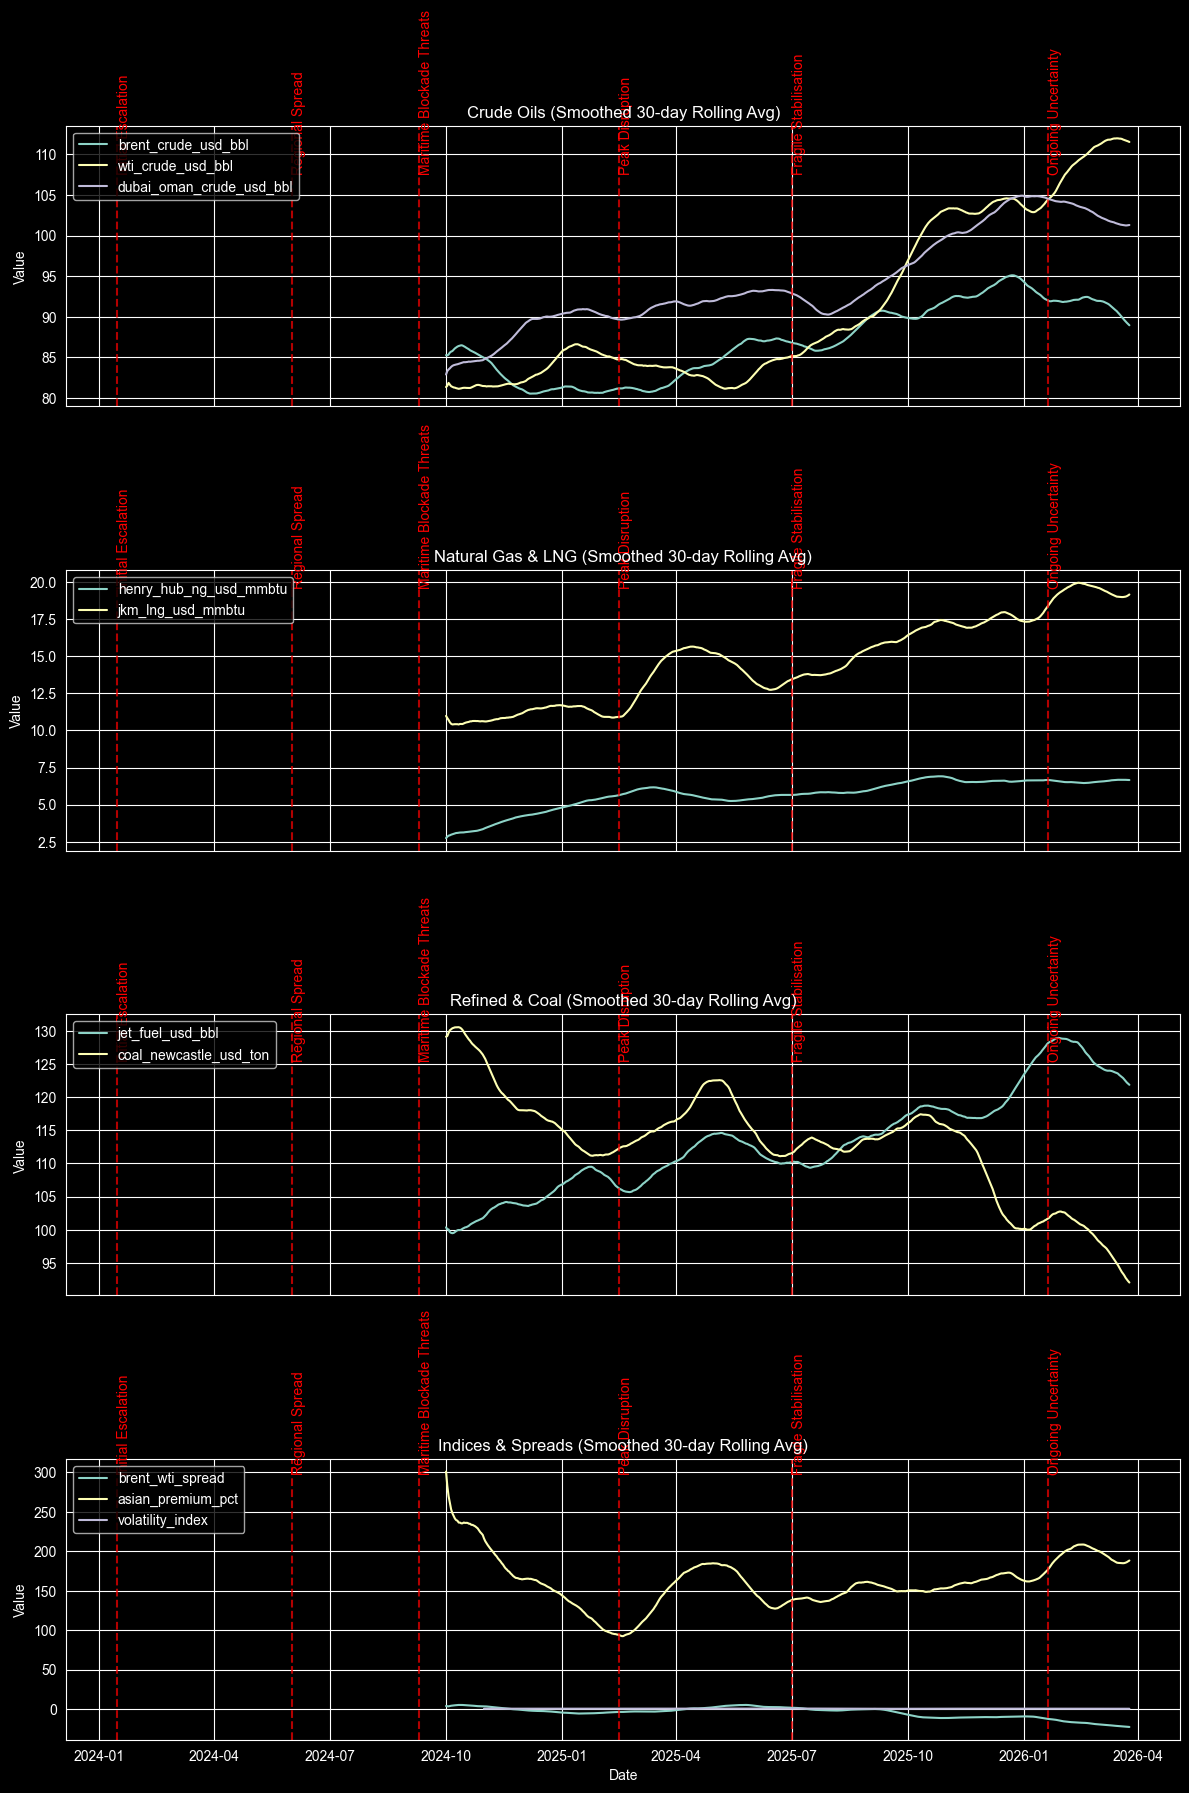

In [2]:


# Join fact_price with dim_date for readable dates
df_price = fact_price.merge(dim_date, on="date_key").sort_values("date")

# Convert date column to datetime
df_price["date"] = pd.to_datetime(df_price["date"])

# Apply rolling average smoothing
window = 30
df_price_smoothed = df_price.copy()
for col in [
    "brent_crude_usd_bbl", "wti_crude_usd_bbl", "dubai_oman_crude_usd_bbl",
    "henry_hub_ng_usd_mmbtu", "jkm_lng_usd_mmbtu",
    "jet_fuel_usd_bbl", "coal_newcastle_usd_ton",
    "brent_wti_spread", "asian_premium_pct", "volatility_index"
]:
    df_price_smoothed[col] = df_price[col].rolling(window=window, min_periods=1).mean()

# Define groups
groups = {
    "Crude Oils": ["brent_crude_usd_bbl", "wti_crude_usd_bbl", "dubai_oman_crude_usd_bbl"],
    "Natural Gas & LNG": ["henry_hub_ng_usd_mmbtu", "jkm_lng_usd_mmbtu"],
    "Refined & Coal": ["jet_fuel_usd_bbl", "coal_newcastle_usd_ton"],
    "Indices & Spreads": ["brent_wti_spread", "asian_premium_pct", "volatility_index"]
}

# Conflict phases with example dates (replace with actual dates from your schema)
phase_dates = {
    "Initial Escalation": "2024-01-15",
    "Regional Spread": "2024-06-01",
    "Maritime Blockade Threats": "2024-09-10",
    "Peak Disruption": "2025-02-15",
    "Fragile Stabilisation": "2025-07-01",
    "Ongoing Uncertainty": "2026-01-20"
}

# Plot grouped subplots
fig, axes = plt.subplots(len(groups), 1, figsize=(12, 18), sharex=True)

for ax, (group_name, cols) in zip(axes, groups.items()):
    for col in cols:
        sns.lineplot(data=df_price_smoothed, x="date", y=col, ax=ax, label=col)
    ax.set_title(f"{group_name} (Smoothed {window}-day Rolling Avg)")
    ax.set_ylabel("Value")
    ax.legend(loc="upper left")

    # Add vertical lines for conflict phases
    for phase, date in phase_dates.items():
        ax.axvline(pd.to_datetime(date), color="red", linestyle="--", alpha=0.7)
        ax.text(pd.to_datetime(date), ax.get_ylim()[1]*0.95, phase, rotation=90, color="red")

plt.xlabel("Date")
plt.tight_layout()
plt.show()


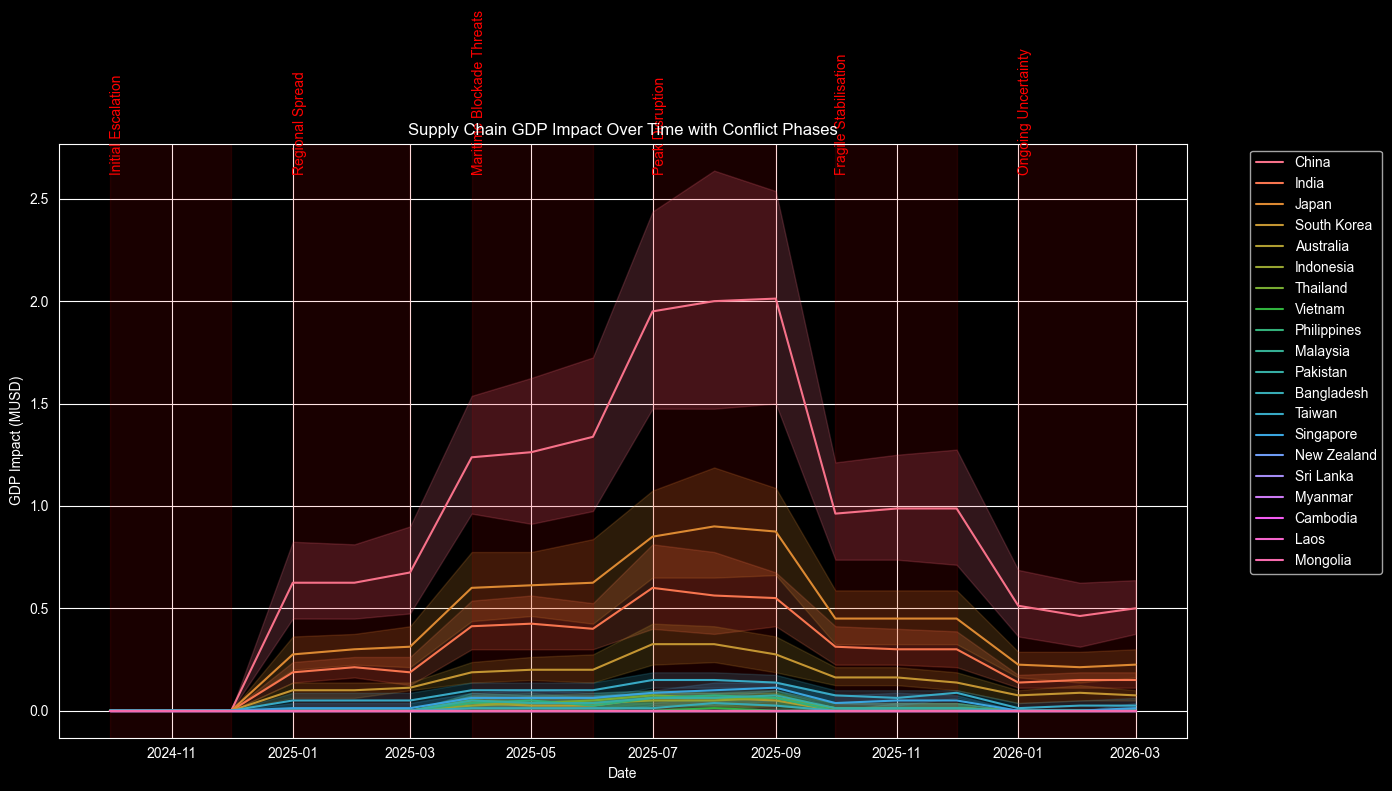

In [3]:
# Join fact table with all dimensions using surrogate keys
df_supply = (fact_supply_chain
             .merge(dim_date, on="date_key")
             .merge(dim_country, on="country_key")
             .merge(dim_conflict_phase, on="conflict_phase_key"))

# Ensure date is datetime
df_supply["date"] = pd.to_datetime(df_supply["date"])

plt.figure(figsize=(14,8))
sns.lineplot(data=df_supply, x="date", y="estimated_gdp_impact_musd", hue="country")

plt.title("Supply Chain GDP Impact Over Time with Conflict Phases")
plt.xlabel("Date")
plt.ylabel("GDP Impact (MUSD)")

# Shade background by conflict phase
for phase in df_supply["conflict_phase"].unique():
    phase_data = df_supply[df_supply["conflict_phase"] == phase]
    start = phase_data["date"].min()
    end = phase_data["date"].max()
    plt.axvspan(start, end, color="red", alpha=0.1)
    plt.text(start, plt.ylim()[1]*0.95, phase, rotation=90, color="red")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [4]:
# Join fact_imports with all dimensions
df_imports = (fact_imports
              .merge(dim_date, on="date_key")
              .merge(dim_country, on="country_key")
              .merge(dim_conflict_phase, on="conflict_phase_key")
              .merge(dim_fuel_type, on="fuel_type_key"))

df_imports["date"] = pd.to_datetime(df_imports["date"])


fig = px.line(
    df_imports,
    x="date",
    y="import_volume_kbpd",
    color="fuel_type",
    line_group="country",
    hover_data={
        "country": True,
        "fuel_type": True,
        "conflict_phase": True,
        "import_volume_kbpd": ':.1f',
        "me_share_pct": ':.2f',
        "alternative_source_pct": ':.2f',
        "price_premium_pct": ':.2f',
        "disruption_risk_score": True,
        "spr_days_cover": True
    }
)

# Shade conflict phases
for phase in df_imports["conflict_phase"].unique():
    phase_data = df_imports[df_imports["conflict_phase"] == phase]
    start = phase_data["date"].min()
    end = phase_data["date"].max()
    fig.add_vrect(
        x0=start, x1=end,
        fillcolor="red", opacity=0.1,
        annotation_text=phase, annotation_position="top left"
    )

fig.update_layout(
    title="Fuel Import Volumes Over Time with Conflict Phases",
    xaxis_title="Date",
    yaxis_title="Import Volume (kbpd)"
)

fig.show()


In [7]:
# --- Price fact ---
df_price = (fact_price
            .merge(dim_date, on="date_key")
            .merge(dim_conflict_phase, on="conflict_phase_key"))
df_price["date"] = pd.to_datetime(df_price["date"])

# --- Supply chain fact ---
df_supply = (fact_supply_chain
             .merge(dim_date, on="date_key")
             .merge(dim_country, on="country_key")
             .merge(dim_conflict_phase, on="conflict_phase_key"))
df_supply["date"] = pd.to_datetime(df_supply["date"])

# --- Imports fact ---
df_imports = (fact_imports
              .merge(dim_date, on="date_key")
              .merge(dim_country, on="country_key")
              .merge(dim_conflict_phase, on="conflict_phase_key")
              .merge(dim_fuel_type, on="fuel_type_key"))
df_imports["date"] = pd.to_datetime(df_imports["date"])


In [12]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    subplot_titles=("Energy Prices (Brent Crude)",
                    "Supply Chain GDP Impact",
                    "Fuel Import Volumes by Fuel Type")
)

# --- 1. Energy Prices ---
fig.add_trace(
    go.Scatter(
        x=df_price["date"],
        y=df_price["brent_crude_usd_bbl"],
        mode="lines",
        name="Brent Crude",
        hovertext=df_price["conflict_phase"]
    ),
    row=1, col=1
)

# --- 2. Supply Chain GDP Impact ---
for country in df_supply["country"].unique():
    country_data = df_supply[df_supply["country"] == country]
    fig.add_trace(
        go.Scatter(
            x=country_data["date"],
            y=country_data["estimated_gdp_impact_musd"],
            mode="lines",
            name=f"GDP Impact - {country}",
            hovertext=country_data["conflict_phase"]
        ),
        row=2, col=1
    )

# --- 3. Imports by Fuel Type ---
for fuel in df_imports["fuel_type"].unique():
    fuel_data = df_imports[df_imports["fuel_type"] == fuel]
    fig.add_trace(
        go.Scatter(
            x=fuel_data["date"],
            y=fuel_data["import_volume_kbpd"],
            mode="lines",
            name=f"{fuel} Imports",
            hovertext=(
                "Country: " + fuel_data["country"] +
                "<br>Phase: " + fuel_data["conflict_phase"] +
                "<br>ME Share: " + fuel_data["me_share_pct"].astype(str) + "%" +
                "<br>Alt Source: " + fuel_data["alternative_source_pct"].astype(str) + "%" +
                "<br>Risk Score: " + fuel_data["disruption_risk_score"].astype(str) +
                "<br>SPR Cover: " + fuel_data["spr_days_cover"].astype(str)
            )
        ),
        row=3, col=1
    )

# --- Shade conflict phases across all panels ---
# --- Shade conflict phases across all panels ---
for phase in df_supply["conflict_phase"].unique():
    phase_data = df_supply[df_supply["conflict_phase"] == phase]
    start = phase_data["date"].min()
    end = phase_data["date"].max()
    fig.add_vrect(
        x0=start, x1=end,
        fillcolor="red", opacity=0.1,
        row="all", col=1
    )


fig.update_layout(
    height=900,
    title_text="Energy → Supply Chain → Imports Dashboard",
    hovermode="x unified"
)

fig.show()
